# 1. Importação de Bibliotecas e Configuração

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# 2. Carregamento e pré-processsamento de dados

In [36]:
# Carregando o dataset Telco Churn
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Mapeamento para PT-BR
dicionario_colunas = {
    'customerID': 'id_cliente', 'gender': 'genero', 'SeniorCitizen': 'idoso',
    'Partner': 'tem_parceiro', 'Dependents': 'dependentes', 'tenure': 'meses_contrato',
    'PhoneService': 'servico_telefone', 'MultipleLines': 'multiplas_linhas',
    'InternetService': 'provedor_internet', 'OnlineSecurity': 'seguranca_online',
    'OnlineBackup': 'backup_online', 'DeviceProtection': 'protecao_dispositivo',
    'TechSupport': 'suporte_tecnico', 'StreamingTV': 'tv_streaming',
    'StreamingMovies': 'filmes_streaming', 'Contract': 'tipo_contrato',
    'PaperlessBilling': 'fatura_digital', 'PaymentMethod': 'forma_pagamento',
    'MonthlyCharges': 'valor_mensal', 'TotalCharges': 'valor_total', 'Churn': 'cancelou'
}
df = df.rename(columns=dicionario_colunas)

# Tratamento de tipos de dados e valores nulos
df['valor_total'] = pd.to_numeric(df['valor_total'], errors='coerce').fillna(0)

# Mapeamento da variável alvo e padronização da variável idoso
df['cancelou'] = df['cancelou'].map({'Yes': 1, 'No': 0})
df['idoso'] = df['idoso'].map({1: 'Yes', 0: 'No'})

# 3. Análise de Poder Preditivo (INFORMATION VALUE - IV)

In [37]:
def calcular_IV(df, coluna_analisada, coluna_churn='cancelou'):
    """Calcula o Information Value (IV) de uma variável categórica."""
    tabela = pd.crosstab(df[coluna_analisada], df[coluna_churn]).reset_index()
    tabela.columns = [coluna_analisada, 'Não Cancelou', 'Cancelou']
    
    qtd_grupo = tabela['Cancelou'] + tabela['Não Cancelou']
    qtd_bons = tabela['Não Cancelou'].sum()
    qtd_maus = tabela['Cancelou'].sum()
    
    perc_bons = tabela['Não Cancelou'] / qtd_bons
    perc_maus = tabela['Cancelou'] / qtd_maus
    
    odds = perc_bons / perc_maus
    ln_odds = np.log(odds)
    iv = (perc_bons - perc_maus) * ln_odds
    
    return round(iv.sum(), 4)

colunas_categoricas = [
    'genero', 'idoso', 'tem_parceiro', 'dependentes', 'servico_telefone', 
    'multiplas_linhas', 'provedor_internet', 'seguranca_online', 'backup_online', 
    'protecao_dispositivo', 'suporte_tecnico', 'tv_streaming', 'filmes_streaming', 
    'tipo_contrato', 'fatura_digital', 'forma_pagamento'
]

resultados_iv = {col: float(calcular_IV(df, col)) for col in colunas_categoricas}
df_iv = pd.DataFrame(list(resultados_iv.items()), columns=['Variável', 'IV Total']).sort_values(by='IV Total', ascending=False).reset_index(drop=True)

# Classificação do IV
condicoes = [
    df_iv['IV Total'] < 0.02,
    (df_iv['IV Total'] >= 0.02) & (df_iv['IV Total'] < 0.10),
    (df_iv['IV Total'] >= 0.10) & (df_iv['IV Total'] < 0.30),
    (df_iv['IV Total'] >= 0.30) & (df_iv['IV Total'] <= 0.50),
    df_iv['IV Total'] > 0.50
]
classificacoes = [
    'Inútil / Sem Poder', 'Poder Fraco', 'Poder Médio', 
    'Poder Forte', 'Suspeito / Muito Forte (Overfitting)'
]
df_iv['Poder Preditivo'] = np.select(condicoes, classificacoes, default='Não Classificado')

print("=== RANKING DE VARIÁVEIS POR IV ===")
display(df_iv.style.format({'IV Total': '{:.4f}'}))

=== RANKING DE VARIÁVEIS POR IV ===


,Variável,IV Total,Poder Preditivo
0,tipo_contrato,1.2386,Suspeito / Muito Forte (Overfitting)
1,seguranca_online,0.7178,Suspeito / Muito Forte (Overfitting)
2,suporte_tecnico,0.6996,Suspeito / Muito Forte (Overfitting)
3,provedor_internet,0.6180,Suspeito / Muito Forte (Overfitting)
4,backup_online,0.5286,Suspeito / Muito Forte (Overfitting)
5,protecao_dispositivo,0.4997,Poder Forte
6,forma_pagamento,0.4571,Poder Forte
7,filmes_streaming,0.3814,Poder Forte
8,tv_streaming,0.3805,Poder Forte
9,fatura_digital,0.2031,Poder Médio


# 4. Análise Temporal e Curva de sobrevida

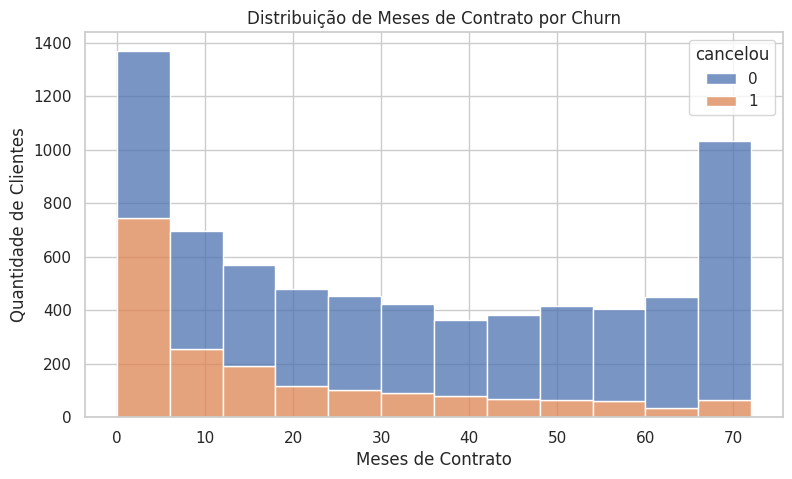

=== EVOLUÇÃO DO CHURN NO 1º ANO ===


,Trimestre,total_clientes,cancelou,Taxa_Churn
0,0 a 3 meses,1062,597,56.21%
1,3 a 6 meses,419,187,44.63%
2,6 a 9 meses,373,139,37.27%
3,9 a 12 meses,332,114,34.34%


In [38]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='meses_contrato', hue='cancelou', bins=12, multiple='stack')
plt.title('Distribuição de Meses de Contrato por Churn')
plt.xlabel('Meses de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

# Detalhamento do Primeiro Ano (Trimestral)
df_primeiro_ano = df[df['meses_contrato'] <= 12].copy()
df_primeiro_ano['Trimestre'] = pd.cut(
    df_primeiro_ano['meses_contrato'],
    bins=[0, 3, 6, 9, 12],
    labels=['0 a 3 meses', '3 a 6 meses', '6 a 9 meses', '9 a 12 meses'],
    include_lowest=True
)

df_trimestral = df_primeiro_ano.groupby('Trimestre', observed=False).agg(
    total_clientes=('cancelou', 'count'),
    cancelou=('cancelou', 'sum'),
    Taxa_Churn=('cancelou', 'mean')
).reset_index()

print("=== EVOLUÇÃO DO CHURN NO 1º ANO ===")
display(df_trimestral.style.format({'Taxa_Churn': '{:.2%}'}).background_gradient(cmap='YlOrRd', subset=['Taxa_Churn']))

# 5. Matriz de Risco Financeiro (MRR PERDIDO X TICKET)

In [39]:
def analisar_matriz_risco(df, coluna_servico):    
    df_temp = df[['valor_mensal', 'cancelou', coluna_servico]].copy()
    df_temp['Ticket'] = pd.cut(df['valor_mensal'], bins=3, labels=['Baixo', 'Médio', 'Alto'], precision=0)
    df_temp['MRR Perdido'] = df_temp['valor_mensal'] * df_temp['cancelou']
    
    resumo = df_temp.groupby(['Ticket', coluna_servico], observed=False).agg(
        clientes=('cancelou', 'count'),
        cancelou=('cancelou', 'sum'),
        Taxa_Churn=('cancelou', 'mean'),
        MRR_perdido=('MRR Perdido', 'sum')        
    )
    return resumo.style.format({
        'Taxa_Churn': '{:.2%}',
        'MRR_perdido': 'R$ {:,.2f}'
    }, thousands='.', decimal=',').bar(subset=['MRR_perdido'], color='#f8d7da', vmin=0).background_gradient(cmap='YlOrRd', subset=['Taxa_Churn'])

print("=== MATRIZ DE RISCO: TOP VARIABLES POR IV ===")
display(analisar_matriz_risco(df, 'tipo_contrato'))
display(analisar_matriz_risco(df, 'seguranca_online'))
display(analisar_matriz_risco(df, 'provedor_internet'))

=== MATRIZ DE RISCO: TOP VARIABLES POR IV ===


# 6. Análise de Cross-Selling e Atrição

In [40]:
colunas_servicos = [
    'seguranca_online', 'suporte_tecnico', 'backup_online', 
    'protecao_dispositivo', 'tv_streaming', 'filmes_streaming'
]

df_qtd_servicos = df.copy()
df_qtd_servicos['qtd_servicos'] = (df_qtd_servicos[colunas_servicos] == 'Yes').sum(axis=1)

df_tx_qtd_serv = df_qtd_servicos.groupby('qtd_servicos', observed=False).agg(
    clientes=('cancelou', 'count'),
    cancelou=('cancelou', 'sum'),
    Taxa_Churn=('cancelou', 'mean')
).reset_index()

print("=== ANOMALIA DE CROSS-SELLING (QTD SERVIÇOS X CHURN) ===")
display(df_tx_qtd_serv.style.format({'Taxa_Churn': '{:.2%}'}).background_gradient(cmap='YlOrRd', subset='Taxa_Churn'))

=== ANOMALIA DE CROSS-SELLING (QTD SERVIÇOS X CHURN) ===


,qtd_servicos,clientes,cancelou,Taxa_Churn
0,0,2219,475,21.41%
1,1,966,442,45.76%
2,2,1033,370,35.82%
3,3,1118,306,27.37%
4,4,852,190,22.30%
5,5,571,71,12.43%
6,6,284,15,5.28%
